In [1]:
import pandas as pd
import numpy as np
import time

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.cluster import (
    KMeans,
    DBSCAN,
    AgglomerativeClustering,
    SpectralClustering,
    OPTICS
)

from sklearn.mixture import GaussianMixture

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

In [2]:
df = pd.read_csv(r"C:\AMRITA\Final_Year_Project_zero_day_27\model_selection_zeroday_fyp_27\UNSW_NB15_training-set.csv")

print(df.shape)

df.head()

(82332, 45)


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.0902,...,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.0003,...,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.0051,...,1,3,0,0,0,1,3,0,Normal,0
3,4,0.000006,udp,-,INT,2,0,900,0,166666.6608,...,1,3,0,0,0,2,3,0,Normal,0
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.0025,...,1,3,0,0,0,2,3,0,Normal,0


In [3]:
selected_features = [

    "dur",

    "proto",

    "service",

    "spkts",

    "dpkts",

    "sbytes",

    "dbytes",

    "rate",

    "sttl",

    "dttl",

    "sload",

    "dload",

    "sinpkt",

    "dinpkt",

    "sjit",

    "djit",

    "tcprtt",

    "synack",

    "ackdat",

    "ct_srv_src",

    "ct_state_ttl",

    "ct_dst_ltm",

    "ct_src_ltm",

    "ct_srv_dst"

]

df = df[selected_features]

df.head()

,dur,proto,service,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,...,sjit,djit,tcprtt,synack,ackdat,ct_srv_src,ct_state_ttl,ct_dst_ltm,ct_src_ltm,ct_srv_dst
0,0.000011,udp,-,2,0,496,0,90909.0902,254,0,...,0.0,0.0,0.0,0.0,0.0,2,2,1,1,2
1,0.000008,udp,-,2,0,1762,0,125000.0003,254,0,...,0.0,0.0,0.0,0.0,0.0,2,2,1,1,2
2,0.000005,udp,-,2,0,1068,0,200000.0051,254,0,...,0.0,0.0,0.0,0.0,0.0,3,2,1,1,3
3,0.000006,udp,-,2,0,900,0,166666.6608,254,0,...,0.0,0.0,0.0,0.0,0.0,3,2,2,2,3
4,0.000010,udp,-,2,0,2126,0,100000.0025,254,0,...,0.0,0.0,0.0,0.0,0.0,3,2,2,2,3


In [4]:
# Encode categorical columns

for col in ["proto","service"]:

    le = LabelEncoder()

    df[col] = le.fit_transform(df[col].astype(str))

# Replace infinities

df.replace([np.inf,-np.inf],np.nan,inplace=True)

# Fill missing values

df.fillna(df.median(numeric_only=True),inplace=True)

# Standardize

scaler = StandardScaler()

X = scaler.fit_transform(df)

print(X.shape)

(82332, 24)


In [5]:
results = []

def evaluate_model(model, name, use_sample=False, sample_size=5000):

    start = time.time()
    
    # Use sampled data for memory-intensive algorithms
    data_to_use = X
    if use_sample and X.shape[0] > sample_size:
        sample_idx = np.random.choice(X.shape[0], size=sample_size, replace=False)
        data_to_use = X[sample_idx]
        print(f"Using sample of {sample_size} samples (dataset: {X.shape[0]} samples)")

    labels = model.fit_predict(data_to_use)

    training_time = time.time() - start

    n_clusters = len(set(labels))

    if -1 in labels:
        n_clusters -= 1

    print(name)
    print("Clusters:", n_clusters)

    if n_clusters < 2:

        print("Cannot compute metrics.\n")

        results.append([
            name,
            n_clusters,
            np.nan,
            np.nan,
            np.nan,
            training_time
        ])

        return

    silhouette = silhouette_score(data_to_use, labels)

    db = davies_bouldin_score(data_to_use, labels)

    ch = calinski_harabasz_score(data_to_use, labels)

    print("Silhouette:", silhouette)

    print("Davies-Bouldin:", db)

    print("Calinski-Harabasz:", ch)

    print()

    results.append([
        name,
        n_clusters,
        silhouette,
        db,
        ch,
        training_time
    ])


In [6]:
kmeans = KMeans(

    n_clusters=10,

    random_state=42,

    n_init=10

)

evaluate_model(kmeans,"KMeans")

KMeans
Clusters: 10
Silhouette: 0.36746283344865677
Davies-Bouldin: 0.9310361075246556
Calinski-Harabasz: 13869.200886248329



In [7]:
dbscan = DBSCAN(

    eps=0.8,

    min_samples=10

)

evaluate_model(dbscan,"DBSCAN")

DBSCAN
Clusters: 119
Silhouette: -0.0022274658294821935
Davies-Bouldin: 1.5808942372227468
Calinski-Harabasz: 582.3125889420646



In [8]:
agg = AgglomerativeClustering(

    n_clusters=10

)

evaluate_model(agg,"Agglomerative", use_sample=True)


Using sample of 5000 samples (dataset: 82332 samples)
Agglomerative
Clusters: 10
Silhouette: 0.35594928795988606
Davies-Bouldin: 0.9328681713143034
Calinski-Harabasz: 903.6477314103221



In [9]:
class GMMWrapper:

    def __init__(self,n_clusters):

        self.model = GaussianMixture(

            n_components=n_clusters,

            random_state=42

        )

    def fit_predict(self,X):

        return self.model.fit_predict(X)

gmm = GMMWrapper(10)

evaluate_model(gmm,"Gaussian Mixture")

Gaussian Mixture
Clusters: 10
Silhouette: 0.20643405515064286
Davies-Bouldin: 1.7702059485572146
Calinski-Harabasz: 7017.0965494667325



In [10]:
spectral = SpectralClustering(

    n_clusters=10,

    random_state=42,

    assign_labels="kmeans"

)

evaluate_model(spectral,"Spectral", use_sample=True)


Using sample of 5000 samples (dataset: 82332 samples)


c:\Users\madhu\anaconda3\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
c:\Users\madhu\anaconda3\Lib\site-packages\sklearn\base.py:1336: ConvergenceWarning: Number of distinct clusters (3) found smaller than n_clusters (10). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


Spectral
Clusters: 3
Silhouette: 0.8275615395821576
Davies-Bouldin: 0.11159785826637358
Calinski-Harabasz: 60.85989404642846



In [11]:
optics = OPTICS(

    min_samples=10

)

evaluate_model(optics,"OPTICS")

c:\Users\madhu\anaconda3\Lib\site-packages\sklearn\cluster\_optics.py:1084: RuntimeWarning: divide by zero encountered in divide
  ratio = reachability_plot[:-1] / reachability_plot[1:]


OPTICS
Clusters: 1680
Silhouette: -0.22965513292624165
Davies-Bouldin: 0.987616909806083
Calinski-Harabasz: 37.41511840677942



In [12]:
results_df = pd.DataFrame(

    results,

    columns=[

        "Model",

        "Clusters",

        "Silhouette",

        "Davies-Bouldin",

        "Calinski-Harabasz",

        "Training Time (s)"

    ]

)

results_df.sort_values(

    by="Silhouette",

    ascending=False

)

,Model,Clusters,Silhouette,Davies-Bouldin,Calinski-Harabasz,Training Time (s)
4,Spectral,3,0.827562,0.111598,60.859894,1063.374351
0,KMeans,10,0.367463,0.931036,13869.200886,4.052634
2,Agglomerative,10,0.355949,0.932868,903.647731,1.350201
3,Gaussian Mixture,10,0.206434,1.770206,7017.096549,23.608332
1,DBSCAN,119,-0.002227,1.580894,582.312589,52.872966
5,OPTICS,1680,-0.229655,0.987617,37.415118,1553.389007


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

k_results = []

for k in range(2, 16):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X)

    k_results.append({
        "k": k,
        "Silhouette": silhouette_score(X, labels),
        "Davies-Bouldin": davies_bouldin_score(X, labels),
        "Calinski-Harabasz": calinski_harabasz_score(X, labels)
    })

k_results = pd.DataFrame(k_results)

display(k_results)

,k,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,2,0.248097,1.682894,14442.796018
1,3,0.272011,1.541087,13079.922027
2,4,0.322468,1.373101,12406.444717
3,5,0.332680,1.214429,12775.748191
4,6,0.354666,1.020995,12817.479828
5,7,0.358266,0.926962,14095.812964
6,8,0.361121,0.920045,13937.144556
7,9,0.353461,0.934574,13629.074446
8,10,0.367463,0.931036,13869.200886
9,11,0.369611,0.839796,14400.529038


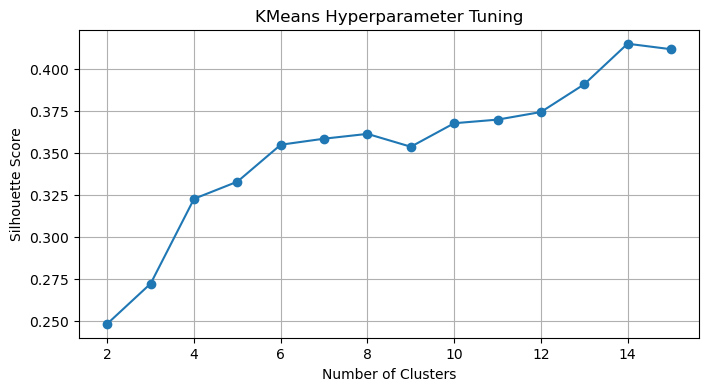

In [14]:
plt.figure(figsize=(8,4))
plt.plot(k_results["k"], k_results["Silhouette"], marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("KMeans Hyperparameter Tuning")
plt.grid(True)
plt.show()

In [15]:
from sklearn.cluster import DBSCAN

dbscan_results = []

eps_values = [0.2,0.4,0.6,0.8,1.0,1.2]
min_samples_values = [5,10,20]

for eps in eps_values:

    for ms in min_samples_values:

        model = DBSCAN(
            eps=eps,
            min_samples=ms
        )

        labels = model.fit_predict(X)

        n_clusters = len(set(labels))

        if -1 in labels:
            n_clusters -= 1

        if n_clusters < 2:
            continue

        dbscan_results.append({

            "eps": eps,

            "min_samples": ms,

            "Clusters": n_clusters,

            "Silhouette": silhouette_score(X, labels),

            "Davies-Bouldin": davies_bouldin_score(X, labels),

            "Calinski-Harabasz": calinski_harabasz_score(X, labels)

        })

dbscan_results = pd.DataFrame(dbscan_results)

display(dbscan_results.sort_values("Silhouette",ascending=False))

,eps,min_samples,Clusters,Silhouette,Davies-Bouldin,Calinski-Harabasz
17,1.2,20,34,0.113903,1.695578,1743.852963
15,1.2,5,100,0.072567,1.646260,819.600932
16,1.2,10,65,0.052474,1.698890,1097.788870
11,0.8,20,71,0.026518,1.650723,859.162722
14,1.0,20,49,0.009830,1.705164,1178.761889
10,0.8,10,119,-0.002227,1.580894,582.312589
13,1.0,10,85,-0.007568,1.598266,799.111721
12,1.0,5,137,-0.008716,1.564867,585.922119
8,0.6,20,105,-0.014387,1.543582,572.906339
7,0.6,10,219,-0.021530,1.515608,321.344072


In [16]:
from sklearn.cluster import AgglomerativeClustering

agg_results = []

sample_size = 5000
if X.shape[0] > sample_size:
    sample_idx = np.random.choice(X.shape[0], size=sample_size, replace=False)
    X_sample = X[sample_idx]
    print(f"Using sample of {sample_size} samples for Agglomerative clustering")
else:
    X_sample = X

for k in range(2,16):

    model = AgglomerativeClustering(
        n_clusters=k
    )

    labels = model.fit_predict(X_sample)

    agg_results.append({

        "Clusters":k,

        "Silhouette":silhouette_score(X_sample, labels),

        "Davies-Bouldin":davies_bouldin_score(X_sample, labels),

        "Calinski-Harabasz":calinski_harabasz_score(X_sample, labels)

    })

agg_results = pd.DataFrame(agg_results)

display(agg_results.sort_values("Silhouette", ascending=False))

Using sample of 5000 samples for Agglomerative clustering


,Clusters,Silhouette,Davies-Bouldin,Calinski-Harabasz
13,15,0.410410,0.903002,1089.790112
12,14,0.399231,0.916811,1074.155140
11,13,0.398394,0.986369,1027.987622
10,12,0.382418,0.990019,996.863339
9,11,0.372490,1.050541,972.494430
8,10,0.368830,1.095433,952.760742
5,7,0.356330,1.000057,961.963648
7,9,0.346841,0.975873,942.220016
4,6,0.342988,1.014715,974.558443
6,8,0.340451,1.017427,944.907401


In [17]:
from sklearn.mixture import GaussianMixture

gmm_results = []

for k in range(2,16):

    model = GaussianMixture(
        n_components=k,
        random_state=42
    )

    labels = model.fit_predict(X)

    gmm_results.append({

        "Clusters":k,

        "Silhouette":silhouette_score(X,labels),

        "Davies-Bouldin":davies_bouldin_score(X,labels),

        "Calinski-Harabasz":calinski_harabasz_score(X,labels)

    })

gmm_results = pd.DataFrame(gmm_results)

display(gmm_results.sort_values("Silhouette", ascending=False))

,Clusters,Silhouette,Davies-Bouldin,Calinski-Harabasz
4,6,0.254840,2.278804,7494.627440
5,7,0.250619,2.244949,6643.701473
2,4,0.244970,1.913031,9243.243412
6,8,0.241434,1.989819,7101.114292
0,2,0.238426,1.715671,13655.788807
3,5,0.236238,1.888002,8302.800148
1,3,0.235359,2.559780,8695.162646
7,9,0.212307,1.813754,7288.079319
8,10,0.206434,1.770206,7017.096549
11,13,0.176743,2.100765,5123.163798


In [18]:
from sklearn.cluster import SpectralClustering

spectral_results = []

sample_size = 5000
if X.shape[0] > sample_size:
    sample_idx = np.random.choice(X.shape[0], size=sample_size, replace=False)
    X_sample_spectral = X[sample_idx]
    print(f"Using sample of {sample_size} samples for Spectral clustering")
else:
    X_sample_spectral = X

for k in range(2,11):

    model = SpectralClustering(
        n_clusters=k,
        random_state=42,
        assign_labels="kmeans",
        affinity="nearest_neighbors",
        n_neighbors=20
    )

    labels = model.fit_predict(X_sample_spectral)

    spectral_results.append({

        "Clusters":k,

        "Silhouette":silhouette_score(X_sample_spectral, labels),

        "Davies-Bouldin":davies_bouldin_score(X_sample_spectral, labels),

        "Calinski-Harabasz":calinski_harabasz_score(X_sample_spectral, labels)

    })

spectral_results = pd.DataFrame(spectral_results)

display(spectral_results.sort_values("Silhouette", ascending=False))

Using sample of 5000 samples for Spectral clustering


c:\Users\madhu\anaconda3\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
c:\Users\madhu\anaconda3\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
c:\Users\madhu\anaconda3\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
c:\Users\madhu\anaconda3\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
c:\Users\madhu\anaconda3\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
c:\Users\madhu\anaconda3\Lib\site-p

,Clusters,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,2,0.584834,0.321382,284.654816
1,3,0.268958,1.189242,636.310046
6,8,0.174159,1.502241,401.741749
7,9,0.173681,1.447796,365.807235
5,7,0.163243,1.549545,441.762236
4,6,0.162772,1.389068,454.447057
8,10,0.150527,1.421836,364.432853
3,5,0.122652,1.321843,488.019715
2,4,0.055100,1.269910,461.858525


In [19]:
from sklearn.cluster import OPTICS
import warnings

optics_results = []

sample_size = 5000
if X.shape[0] > sample_size:
    sample_idx = np.random.choice(X.shape[0], size=sample_size, replace=False)
    X_sample_optics = X[sample_idx]
    print(f"Using sample of {sample_size} samples for OPTICS")
else:
    X_sample_optics = X

for ms in [5,10,20,30]:

    with warnings.catch_warnings():
        warnings.filterwarnings('ignore', category=RuntimeWarning)
        
        model = OPTICS(
            min_samples=ms
        )

        labels = model.fit_predict(X_sample_optics)

    n_clusters = len(set(labels))

    if -1 in labels:
        n_clusters -= 1

    if n_clusters < 2:
        continue

    optics_results.append({

        "min_samples":ms,

        "Clusters":n_clusters,

        "Silhouette":silhouette_score(X_sample_optics,labels),

        "Davies-Bouldin":davies_bouldin_score(X_sample_optics,labels),

        "Calinski-Harabasz":calinski_harabasz_score(X_sample_optics,labels)

    })

optics_results = pd.DataFrame(optics_results)

display(optics_results.sort_values("Silhouette",ascending=False))

Using sample of 5000 samples for OPTICS


,min_samples,Clusters,Silhouette,Davies-Bouldin,Calinski-Harabasz
2,20,29,-0.336058,1.357187,42.091684
1,10,71,-0.349619,1.197475,34.582256
0,5,206,-0.357141,1.155337,12.852144
3,30,15,-0.367506,1.281585,66.823039


In [20]:
comparison = pd.DataFrame({

    "Model":[
        "KMeans",
        "DBSCAN",
        "Agglomerative",
        "Gaussian Mixture",
        "Spectral",
        "OPTICS"
    ],

    "Best Silhouette":[
        k_results["Silhouette"].max(),
        dbscan_results["Silhouette"].max(),
        agg_results["Silhouette"].max(),
        gmm_results["Silhouette"].max(),
        spectral_results["Silhouette"].max(),
        optics_results["Silhouette"].max()
    ]

})

comparison = comparison.sort_values(
    by="Best Silhouette",
    ascending=False
)

display(comparison)

,Model,Best Silhouette
4,Spectral,0.584834
0,KMeans,0.414801
2,Agglomerative,0.410410
3,Gaussian Mixture,0.254840
1,DBSCAN,0.113903
5,OPTICS,-0.336058


In [21]:
# Additional comparison using Davie–Bouldin, Calinski–Harabasz, runtime, and memory estimates.
metrics_summary = []
for model_name, df_model in {
    "KMeans": k_results,
    "DBSCAN": dbscan_results,
    "Agglomerative": agg_results,
    "Gaussian Mixture": gmm_results,
    "Spectral": spectral_results,
    "OPTICS": optics_results
}.items():
    df_model = df_model.dropna(subset=["Silhouette", "Davies-Bouldin", "Calinski-Harabasz"])
    if df_model.empty:
        continue
    best_idx = df_model["Silhouette"].idxmax()
    best_row = df_model.loc[best_idx]
    metrics_summary.append({
        "Model": model_name,
        "Best Silhouette": best_row["Silhouette"],
        "Best Davies-Bouldin": best_row["Davies-Bouldin"],
        "Best Calinski-Harabasz": best_row["Calinski-Harabasz"]
    })

metrics_df = pd.DataFrame(metrics_summary)
metrics_df["Training Time (s)"] = metrics_df["Model"].map(
    results_df.set_index("Model")["Training Time (s)"]
)
metrics_df["Memory Usage"] = metrics_df["Model"].map({
    "KMeans": "Low",
    "DBSCAN": "Moderate",
    "Agglomerative": "High",
    "Gaussian Mixture": "Moderate",
    "Spectral": "High",
    "OPTICS": "Moderate"
})

metrics_df["Silhouette Rank"] = metrics_df["Best Silhouette"].rank(ascending=False, method="min").astype(int)
metrics_df["DB Rank"] = metrics_df["Best Davies-Bouldin"].rank(ascending=True, method="min").astype(int)
metrics_df["CH Rank"] = metrics_df["Best Calinski-Harabasz"].rank(ascending=False, method="min").astype(int)
metrics_df["Time Rank"] = metrics_df["Training Time (s)"].rank(ascending=True, method="min").astype(int)
metrics_df["Overall Score"] = (
    metrics_df["Silhouette Rank"]
    + metrics_df["DB Rank"]
    + metrics_df["CH Rank"]
    + metrics_df["Time Rank"]
) / 4

metrics_df = metrics_df.sort_values("Overall Score")

display(metrics_df[[
    "Model",
    "Best Silhouette",
    "Best Davies-Bouldin",
    "Best Calinski-Harabasz",
    "Training Time (s)",
    "Memory Usage"
]])

print("---")

display(metrics_df[[
    "Model",
    "Silhouette Rank",
    "DB Rank",
    "CH Rank",
    "Time Rank",
    "Overall Score"
]])

,Model,Best Silhouette,Best Davies-Bouldin,Best Calinski-Harabasz,Training Time (s),Memory Usage
0,KMeans,0.414801,0.842068,15880.479470,4.052634,Low
2,Agglomerative,0.410410,0.903002,1089.790112,1.350201,High
4,Spectral,0.584834,0.321382,284.654816,1063.374351,High
3,Gaussian Mixture,0.254840,2.278804,7494.627440,23.608332,Moderate
1,DBSCAN,0.113903,1.695578,1743.852963,52.872966,Moderate
5,OPTICS,-0.336058,1.357187,42.091684,1553.389007,Moderate


---


,Model,Silhouette Rank,DB Rank,CH Rank,Time Rank,Overall Score
0,KMeans,2,2,1,2,1.75
2,Agglomerative,3,3,4,1,2.75
4,Spectral,1,1,5,5,3.00
3,Gaussian Mixture,4,6,2,3,3.75
1,DBSCAN,5,5,3,4,4.25
5,OPTICS,6,4,6,6,5.50
